In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


In [4]:
DATA_DIR = r"C:\Users\Mathumitha\Desktop\Mathu\veg"  
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "validation")
TEST_DIR  = os.path.join(DATA_DIR, "test")


In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)


Found 858 files belonging to 10 classes.


In [7]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)


Found 98 files belonging to 10 classes.


In [8]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="int"
)

Found 100 files belonging to 10 classes.


In [9]:
class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)


Classes: ['beetroot', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'cucumber', 'eggplant', 'potato', 'raddish', 'tomato']


In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)

In [11]:

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])


In [12]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False


In [13]:
model = keras.Sequential([

    layers.Input(shape=(224,224,3)),

    data_augmentation,

    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")

])

In [14]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,362 (9.26 MB)

 Trainable params: 167,818 (655.54 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [15]:
callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3
    )

]

In [16]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)


Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 35s 450ms/step - accuracy: 0.2028 - loss: 2.7615 - val_accuracy: 0.5204 - val_loss: 1.5749 - learning_rate: 1.0000e-04
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 409ms/step - accuracy: 0.4977 - loss: 1.6330 - val_accuracy: 0.8163 - val_loss: 0.9317 - learning_rate: 1.0000e-04
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 408ms/step - accuracy: 0.5956 - loss: 1.2142 - val_accuracy: 0.8776 - val_loss: 0.5765 - learning_rate: 1.0000e-04
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 19s 356ms/step - accuracy: 0.6876 - loss: 0.9718 - val_accuracy: 0.8980 - val_loss: 0.4044 - learning_rate: 1.0000e-04
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 405ms/step - accuracy: 0.7296 - loss: 0.8223 - val_accuracy: 0.9286 - val_loss: 0.3055 - learning_rate: 1.0000e-04
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 21s 395ms/step - accuracy: 0.7902 - loss: 0.6359 - val_accuracy: 0.9286 - val_loss: 0.2486 - learning_rate: 1.0000e-04
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 24s 441ms/step - acc

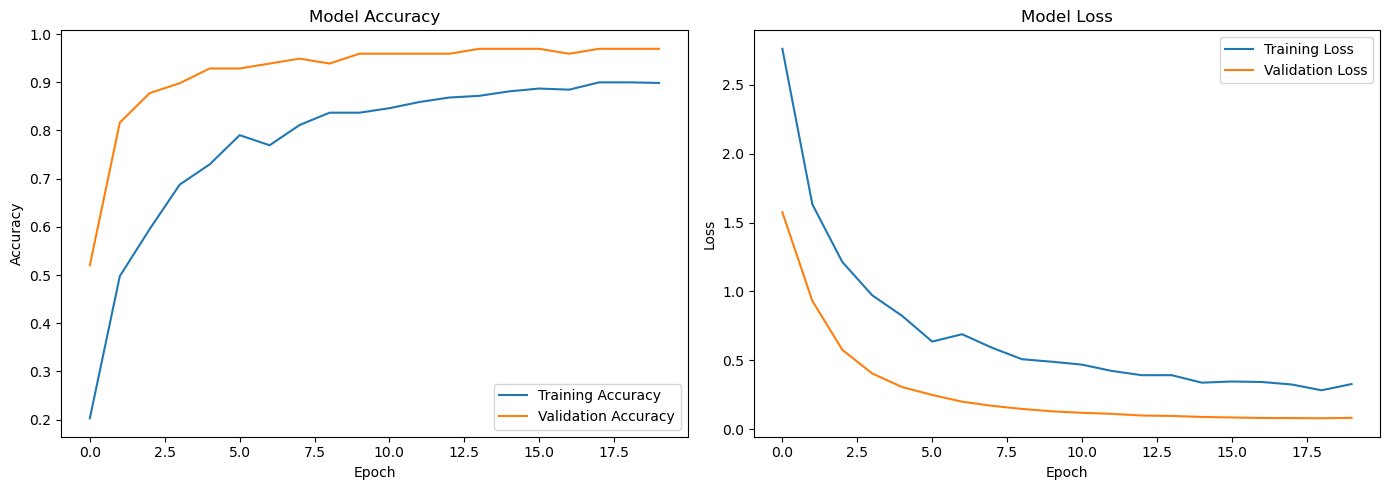

In [17]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Loss")
plt.legend()

plt.tight_layout()
plt.show()


In [18]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"\nTest Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 259ms/step - accuracy: 0.9700 - loss: 0.0797

Test Accuracy: 97.00%
Test Loss: 0.0797


In [19]:
y_true = np.concatenate([y for x,y in test_ds], axis=0)

y_pred_prob = model.predict(test_ds)
y_pred = np.argmax(y_pred_prob, axis=1)


7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 498ms/step


In [20]:
print("\nClassification Report")
print("="*60)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=3
))



Classification Report
              precision    recall  f1-score   support

    beetroot      1.000     1.000     1.000        10
     cabbage      1.000     1.000     1.000        10
    capsicum      1.000     1.000     1.000        10
      carrot      1.000     0.900     0.947        10
 cauliflower      1.000     1.000     1.000        10
    cucumber      1.000     1.000     1.000        10
    eggplant      1.000     0.900     0.947        10
      potato      1.000     0.900     0.947        10
     raddish      0.833     1.000     0.909        10
      tomato      0.909     1.000     0.952        10

    accuracy                          0.970       100
   macro avg      0.974     0.970     0.970       100
weighted avg      0.974     0.970     0.970       100



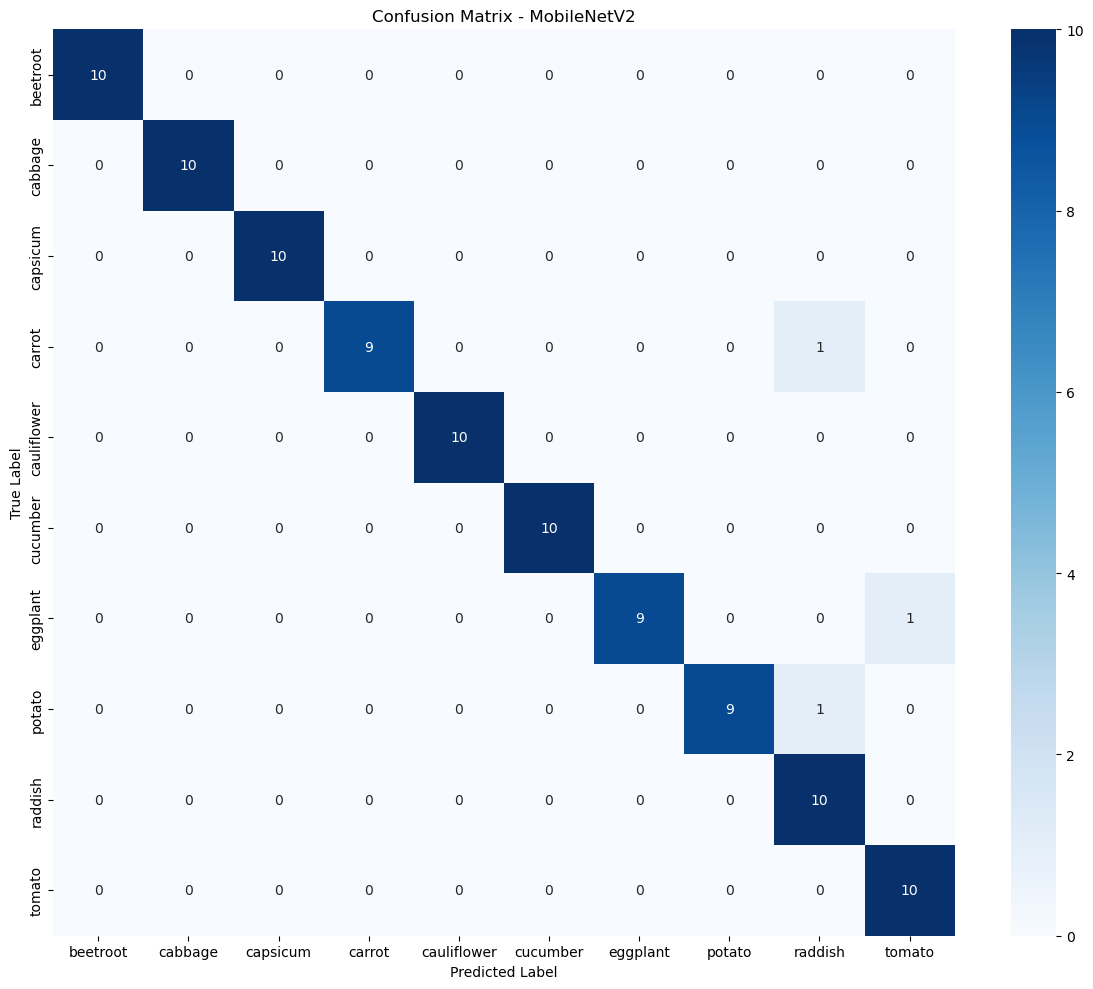

In [21]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - MobileNetV2")

plt.tight_layout()
plt.show()


In [22]:
model.save("vegetable_mobilenet_model.keras")

print("\nMobileNet model saved successfully!")


MobileNet model saved successfully!
